In [80]:
import pandas as pd
import numpy as np

import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline

from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction import DictVectorizer
from sklearn.metrics import roc_auc_score, root_mean_squared_error
from sklearn.tree import export_text
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

## 1. Data Preparation

In [4]:
data = 'https://github.com/alexeygrigorev/datasets/raw/refs/heads/master/jamb_exam_results.csv'

In [5]:
df = pd.read_csv(data)
df.head()

,JAMB_Score,Study_Hours_Per_Week,Attendance_Rate,Teacher_Quality,Distance_To_School,School_Type,School_Location,Extra_Tutorials,Access_To_Learning_Materials,Parent_Involvement,IT_Knowledge,Student_ID,Age,Gender,Socioeconomic_Status,Parent_Education_Level,Assignments_Completed
0,192,22,78,4,12.4,Public,Urban,Yes,Yes,High,Medium,1,17,Male,Low,Tertiary,2
1,207,14,88,4,2.7,Public,Rural,No,Yes,High,High,2,15,Male,High,NaN,1
2,182,29,87,2,9.6,Public,Rural,Yes,Yes,High,Medium,3,20,Female,High,Tertiary,2
3,210,29,99,2,2.6,Public,Urban,No,Yes,Medium,High,4,22,Female,Medium,Tertiary,1
4,199,12,98,3,8.8,Public,Urban,No,Yes,Medium,Medium,5,22,Female,Medium,Tertiary,1


In [6]:
# change the columns to lower case
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [7]:
df.head().T

,0,1,2,3,4
jamb_score,192,207,182,210,199
study_hours_per_week,22,14,29,29,12
attendance_rate,78,88,87,99,98
teacher_quality,4,4,2,2,3
distance_to_school,12.4,2.7,9.6,2.6,8.8
school_type,Public,Public,Public,Public,Public
school_location,Urban,Rural,Rural,Urban,Urban
extra_tutorials,Yes,No,Yes,No,No
access_to_learning_materials,Yes,Yes,Yes,Yes,Yes
parent_involvement,High,High,High,Medium,Medium


In [8]:
# remove student_id columns

del df['student_id']

In [9]:
# missing value
df.isnull().sum()

jamb_score                        0
study_hours_per_week              0
attendance_rate                   0
teacher_quality                   0
distance_to_school                0
school_type                       0
school_location                   0
extra_tutorials                   0
access_to_learning_materials      0
parent_involvement                0
it_knowledge                      0
age                               0
gender                            0
socioeconomic_status              0
parent_education_level          891
assignments_completed             0
dtype: int64

In [10]:
df.parent_education_level.value_counts(dropna=False)

parent_education_level
Secondary    1556
Primary      1335
Tertiary     1218
NaN           891
Name: count, dtype: int64

In [11]:
df.parent_education_level = df.parent_education_level.fillna(0)

In [46]:
# Splitting train / test data set

df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

In [50]:
y_full_train = df_full_train['jamb_score']
y_train = df_train['jamb_score']
y_val = df_val['jamb_score']
y_test = df_test['jamb_score']

In [52]:
del df_train['jamb_score']
del df_val['jamb_score']
del df_test['jamb_score']

In [57]:
# Turn the df into matrices 

train_dicts = df_train.to_dict(orient='records')
dv = DictVectorizer(sparse=False)
X_train = dv.fit_transform(train_dicts)

In [59]:
val_dicts = df_val.to_dict(orient='records')
X_val = dv.transform(val_dicts)

## Question 1
Train a decision tree regressor to predict the jamb_score.
- Train a model with max_depth = 1


Using only 1 features, study_hours_per_week is used to split the data.

In [66]:
dt = DecisionTreeRegressor(max_depth=1)
dt.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=1)

In [70]:
print(export_text(dt, feature_names=list(dv.get_feature_names_out())))

|--- study_hours_per_week <= 18.50
|   |--- value: [155.24]
|--- study_hours_per_week >  18.50
|   |--- value: [188.59]



## Question 2

Train a random forest regressor with these parameters:

n_estimators=10
random_state=1
n_jobs=-1 (optional - to make training faster)

What's the RMSE of this model on the validation data?

In [78]:
rf = RandomForestRegressor(n_estimators=10, random_state=1, n_jobs=-1)
rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=10, n_jobs=-1, random_state=1)

In [82]:
y_pred = rf.predict(X_val)

In [84]:
rsme = root_mean_squared_error(y_val, y_pred)
rsme

42.13724207871227

## Question 3

Now let's experiment with the `n_estimators` parameter

* Try different values of this parameter from 10 to 200 with step 10.
* Set `random_state` to `1`.
* Evaluate the model on the validation dataset.


After which value of `n_estimators` does RMSE stop improving?
Consider 3 decimal places for calculating the answer.

In [93]:
rsme_score = []
for n in range(10, 201, 10):
    rf = RandomForestRegressor(n_estimators=n, 
                               random_state=1, n_jobs=-1)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_val)
    rsme = root_mean_squared_error(y_val, y_pred)
    rsme_score.append((n, rsme))

In [97]:
df_rsme = pd.DataFrame(rsme_score, columns=['n_estimator', 'rsme'])

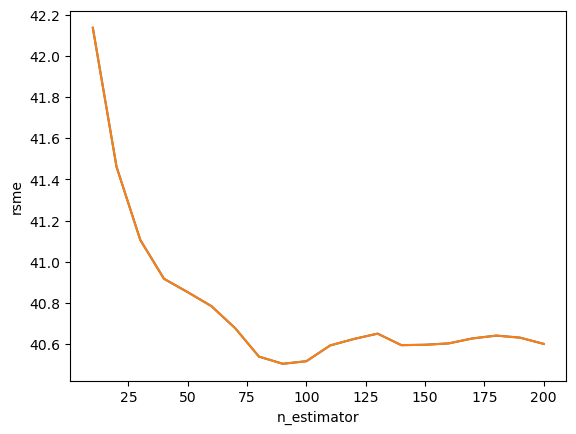

In [105]:
sns.lineplot(df_rsme, x ='n_estimator', y='rsme')
plt.show()

Around 80 estimators, the RMSE stop improving and gets worse.

## Question 4

Let's select the best `max_depth`:

* Try different values of `max_depth`: `[10, 15, 20, 25]`
* For each of these values,
  * try different values of `n_estimators` from 10 till 200 (with step 10)
  * calculate the mean RMSE 
* Fix the random seed: `random_state=1`


What's the best `max_depth`, using the mean RMSE?

In [112]:
rsme_score = []
for d in [10, 15, 20, 25]:
    for n in range(10, 201, 10):
        rf = RandomForestRegressor(max_depth=d, n_estimators=n, 
                                   random_state=1, n_jobs=-1)
        rf.fit(X_train, y_train)
        y_pred = rf.predict(X_val)
        rsme = root_mean_squared_error(y_val, y_pred)
        rsme_score.append((d, n, rsme))

In [114]:
df_rsme = pd.DataFrame(rsme_score, columns=['max_depth', 'n_estimator', 'rsme'])

In [120]:
df_rsme_pivot = df_rsme.pivot(columns='max_depth', index='n_estimator', values='rsme')

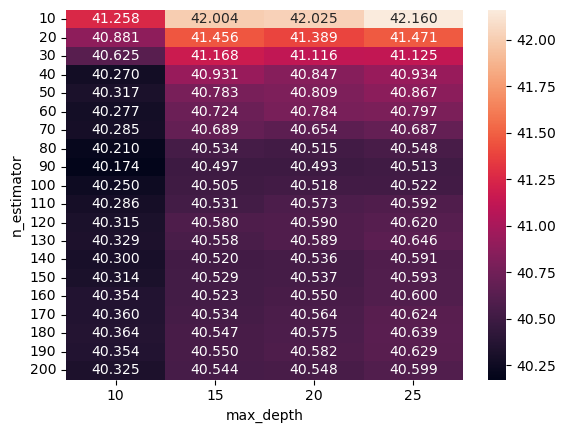

In [128]:
sns.heatmap(df_rsme_pivot, annot=True, fmt='.3f')
plt.show()

The best combination for RF model is with max_depth 10 and n_estimator = 90.

# Question 5

We can extract feature importance information from tree-based models. 

At each step of the decision tree learning algorithm, it finds the best split. 
When doing it, we can calculate "gain" - the reduction in impurity before and after the split. 
This gain is quite useful in understanding what are the important features for tree-based models.

In Scikit-Learn, tree-based models contain this information in the
[`feature_importances_`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html#sklearn.ensemble.RandomForestRegressor.feature_importances_)
field. 

For this homework question, we'll find the most important feature:

* Train the model with these parameters:
  * `n_estimators=10`,
  * `max_depth=20`,
  * `random_state=1`,
  * `n_jobs=-1` (optional)
* Get the feature importance information from this model

In [135]:
rf_5 = RandomForestRegressor(n_estimators=10, max_depth=20, 
                             random_state=1, n_jobs=-1)
rf_5.fit(X_train, y_train)
rf_5.feature_importances_

array([0.0123254 , 0.01026189, 0.06931145, 0.03151679, 0.14972903,
       0.1364858 , 0.01345934, 0.00913136, 0.00928871, 0.01038263,
       0.01771934, 0.01240405, 0.00914148, 0.        , 0.01545036,
       0.01695692, 0.01448862, 0.02291885, 0.01335761, 0.01149201,
       0.00955909, 0.00923932, 0.0089532 , 0.00840598, 0.02571426,
       0.01070798, 0.01056268, 0.24835361, 0.08268222])

In [141]:
df_feature_importance = pd.DataFrame()
df_feature_importance['feature'] = dv.feature_names_
df_feature_importance['importance_score'] = rf_5.feature_importances_
df_feature_importance.sort_values(by='importance_score', ascending=False).head()

,feature,importance_score
27,study_hours_per_week,0.248354
4,attendance_rate,0.149729
5,distance_to_school,0.136486
28,teacher_quality,0.082682
2,age,0.069311


`study_hours_per_week` is the most important feature. It is used in a decision model to split data as well.

## Quesiton 6

In [149]:
features = list(dv.get_feature_names_out())
dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=features)
dval = xgb.DMatrix(X_val, label=y_val, feature_names=features)

In [151]:
watchlist = [(dtrain, 'train'), (dval, 'val')]

In [155]:
scores = {}

In [153]:
def parse_xgb_output(output):
    results = []

    for line in output.stdout.strip().split('\n'):
        it_line, train_line, val_line = line.split('\t')

        it = int(it_line.strip('[]'))
        train = float(train_line.split(':')[1])
        val = float(val_line.split(':')[1])

        results.append((it, train, val))
    
    columns = ['num_iter', 'train_auc', 'val_auc']
    df_results = pd.DataFrame(results, columns=columns)
    return df_results

In [157]:
%%capture output_03

xgb_params = {
    'eta': 0.3, 
    'max_depth': 6,
    'min_child_weight': 1,
    
    'objective': 'reg:squarederror',
    'nthread': 8,
    
    'seed': 1,
    'verbosity': 1,
}

model = xgb.train(xgb_params, dtrain, num_boost_round=100,
                 verbose_eval=5, evals=watchlist)

In [159]:
%%capture output_01

xgb_params = {
    'eta': 0.1, 
    'max_depth': 6,
    'min_child_weight': 1,
    
    'objective': 'reg:squarederror',
    'nthread': 8,
    
    'seed': 1,
    'verbosity': 1,
}

model = xgb.train(xgb_params, dtrain, num_boost_round=100,
                 verbose_eval=5, evals=watchlist)

In [163]:
scores['eta_03'] = parse_xgb_output(output_03)
scores['eta_01'] = parse_xgb_output(output_01)

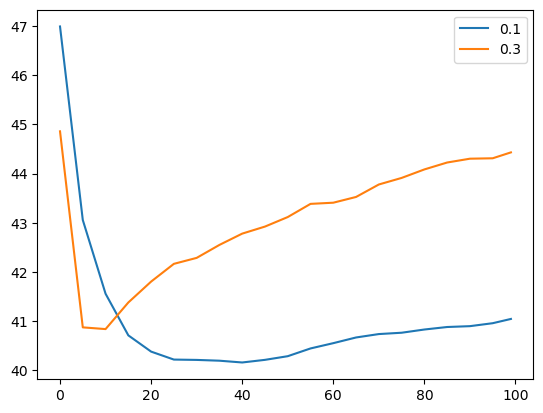

In [167]:
plt.plot(scores['eta_01'].num_iter, scores['eta_01'].val_auc,
        label='0.1')
plt.plot(scores['eta_03'].num_iter, scores['eta_03'].val_auc,
        label='0.3')
plt.legend()
plt.show()